**TUTORIAL**

In [1]:
# Instalación de las versiones más recientes y estables
!pip install -U numpy ultralytics roboflow streamlit -q
!npm install -g localtunnel -q

# IMPORTANTE: Reinicia el entorno (Entorno de ejecución -> Reiniciar sesión)
# después de ejecutar esta celda para aplicar los cambios.

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [2]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="HWr9UU8Z8pGEYJvgTPxV")
project = rf.workspace("sekant").project("my-first-project-4wl7u")
version = project.version(1)
dataset = version.download("yolov8")

# Esta es la ruta que usaremos para entrenar
DATA_YAML = os.path.join(dataset.location, "data.yaml")
print(f"✅ Dataset listo en: {DATA_YAML}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset listo en: /content/My-First-Project-1/data.yaml


In [3]:
!cat /content/My-First-Project-1/data.yaml

names:
- ADP
- AOL
- ASB Bank Limited
- ATB Financial
- Absa Group
- Adobe
- Alaska USA Federal Credit Union
- Alibaba
- Allegro
- Amazon
- American Express
- Americanas-com S
- Apple
- Aruba S-p-A
- AutoScout24
- BH Telecom
- BT Group plc
- BZSt
- Banca Sella
- Banco Safra
- Banco de Chile
- Banco del Estado de Chile
- Banco do Brasil S-A
- Bank Al Habib
- Bank of America
- Bank of Montreal
- Bank of New Zealand
- Bank of Scotland
- Bank of The Bahamas Limited
- Bankia
- Belize Bank
- Bet365
- Bethpage Federal Credit Union
- Blockchain
- Bouygues Telecom
- Cairo Amman Bank
- Caixa Economica Federal
- Caixa Geral de Depositos
- CaixaBank
- Canadian Imperial Bank of Commerce
- Cembra Money Bank AG
- CenturyLink
- Charities Aid Foundation
- Chase Personal Banking
- Chronopost International
- Citrix ShareFile
- Comcast Corporation
- Cox Communications
- Credit Agricole S-A
- Credit Suisse AG
- Credit du Nord
- DGI -French Tax Authority-
- DHL
- Daum
- Delta Air Lines
- Desjardins
- Deutsc

In [4]:
from roboflow import Roboflow
import os

# Tu API Key que ya vimos antes
rf = Roboflow(api_key="HWr9UU8Z8pGEYJvgTPxV")
project = rf.workspace("sekant").project("my-first-project-4wl7u")
version = project.version(1)
dataset = version.download("yolov8")

# Guardamos la ruta para que no se nos pierda
DATA_YAML = os.path.join(dataset.location, "data.yaml")
print(f"✅ Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset descargado en: /content/My-First-Project-1


In [5]:
import os
import sys

# Intentar importar las librerías y corregir incompatibilidad de NumPy si ocurre
try:
    import numpy
    from ultralytics import YOLO
except ValueError:
    print("⚠️ Detectada incompatibilidad de NumPy. Intentando corregir entorno...")
    # Reinstalamos numpy y ultralytics para asegurar que sean compatibles
    get_ipython().system('pip install "numpy>=2.0" ultralytics -U -q')
    import numpy
    from ultralytics import YOLO

# 1. Verificar la versión de Numpy (Debería ser 2.x en entornos actuales de Colab)
print(f"Versión de NumPy activa: {numpy.__version__}")

# 2. Asegurarnos de que la ruta del YAML sea la correcta del dataset
# Priorizamos la ruta descargada por Roboflow
if 'dataset' in locals():
    DATA_YAML = os.path.join(dataset.location, "data.yaml")
else:
    # Ruta estándar si se descargó en My-First-Project-1
    DATA_YAML = "/content/My-First-Project-1/data.yaml"

# 3. Lanzar entrenamiento
if os.path.exists(DATA_YAML):
    print(f"✅ Iniciando entrenamiento con: {DATA_YAML}")
    model = YOLO('yolov8n.pt')
    results = model.train(
        data=DATA_YAML,
        epochs=100,
        imgsz=640
    )
else:
    print(f"❌ ERROR: No se encuentra el archivo {DATA_YAML}")
    print("Por favor, ejecuta la celda de Roboflow para descargar el dataset original.")

Versión de NumPy activa: 2.4.2
✅ Iniciando entrenamiento con: /content/My-First-Project-1/data.yaml
Ultralytics 8.4.10 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2

In [6]:
from google.colab import files
import os

# --- NOTA SOBRE LA RUTA ---
# YOLO guarda por defecto en: /content/runs/detect/train/weights/best.pt
# Si has hecho varios entrenamientos, la carpeta podría ser train2, train3, etc.
# --------------------------

def descargar_modelo(nombre_entrenamiento='train'):
    ruta_pesos = f'/content/runs/detect/{nombre_entrenamiento}/weights/best.pt'

    if os.path.exists(ruta_pesos):
        print(f"✅ Modelo {ruta_pesos} encontrado. Iniciando descarga...")
        files.download(ruta_pesos)
    else:
        print(f"❌ No se encontró el archivo en {ruta_pesos}")
        print("Revisa en la carpeta 'runs' de la izquierda cuál es el nombre correcto (train, train2, etc.)")

# Ejecuta esta función después de model.train()
descargar_modelo('train')

✅ Modelo /content/runs/detect/train/weights/best.pt encontrado. Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📊 Últimas métricas registradas:
metrics/precision(B)    0.63661
metrics/recall(B)       0.48229
metrics/mAP50(B)        0.58081
metrics/mAP50-95(B)     0.55837
Name: 24, dtype: float64


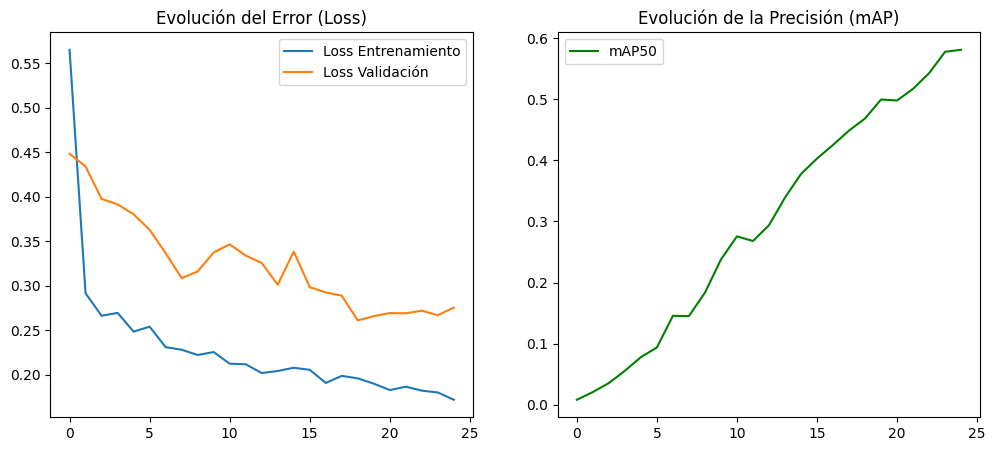

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo de resultados
results_path = 'runs/detect/train/results.csv'
df = pd.read_csv(results_path)

# Limpiar los nombres de las columnas (a veces tienen espacios)
df.columns = [c.strip() for c in df.columns]

# Mostrar las últimas métricas obtenidas
print("📊 Últimas métricas registradas:")
print(df[['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].iloc[-1])

# Graficar la evolución del entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df['train/box_loss'], label='Loss Entrenamiento')
plt.plot(df['val/box_loss'], label='Loss Validación')
plt.title('Evolución del Error (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df['metrics/mAP50(B)'], label='mAP50', color='green')
plt.title('Evolución de la Precisión (mAP)')
plt.legend()
plt.show()

In [8]:
%load_ext tensorboard
import matplotlib.pyplot as plt
import cv2

# YOLO guarda automáticamente la matriz de confusión en la carpeta de resultados
path_matriz = 'runs/detect/train/confusion_matrix.png'

try:
  img = cv2.imread(path_matriz)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(12, 10))
  plt.imshow(img_rgb)
  plt.axis('off')
  plt.title('Mapa de Calor: Matriz de Confusión (YOLOv8)')
  plt.show()
except:
  print("Asegúrate de que la ruta 'runs/detect/train/confusion_matrix.png' sea correcta.")

Asegúrate de que la ruta 'runs/detect/train/confusion_matrix.png' sea correcta.


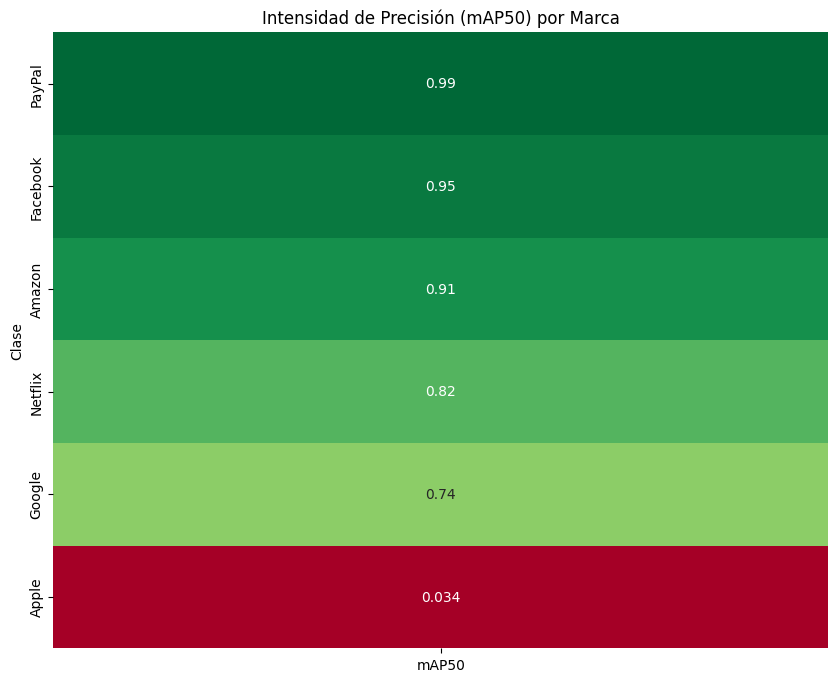

In [9]:
!pip install pandas seaborn matplotlib -q
import pandas as pd
import seaborn as sns

# Extraemos los datos que nos pasaste (ejemplo con las primeras clases)
data = {
    'Clase': ['Amazon', 'Facebook', 'PayPal', 'Apple', 'Google', 'Netflix'],
    'mAP50': [0.913, 0.955, 0.992, 0.034, 0.742, 0.823]
}

df = pd.DataFrame(data).sort_values(by='mAP50', ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df.set_index('Clase'), annot=True, cmap='RdYlGn', cbar=False)
plt.title('Intensidad de Precisión (mAP50) por Marca')
plt.show()

⚠️ Alerta: La marca 'Bet365' solo tiene 1 imágenes. Es imposible que el modelo aprenda así.
⚠️ Alerta: La marca 'Maersk' solo tiene 1 imágenes. Es imposible que el modelo aprenda así.
⚠️ Alerta: La marca 'Uber' solo tiene 2 imágenes. Es imposible que el modelo aprenda así.
⚠️ Alerta: La marca 'Banca Sella' solo tiene 2 imágenes. Es imposible que el modelo aprenda así.


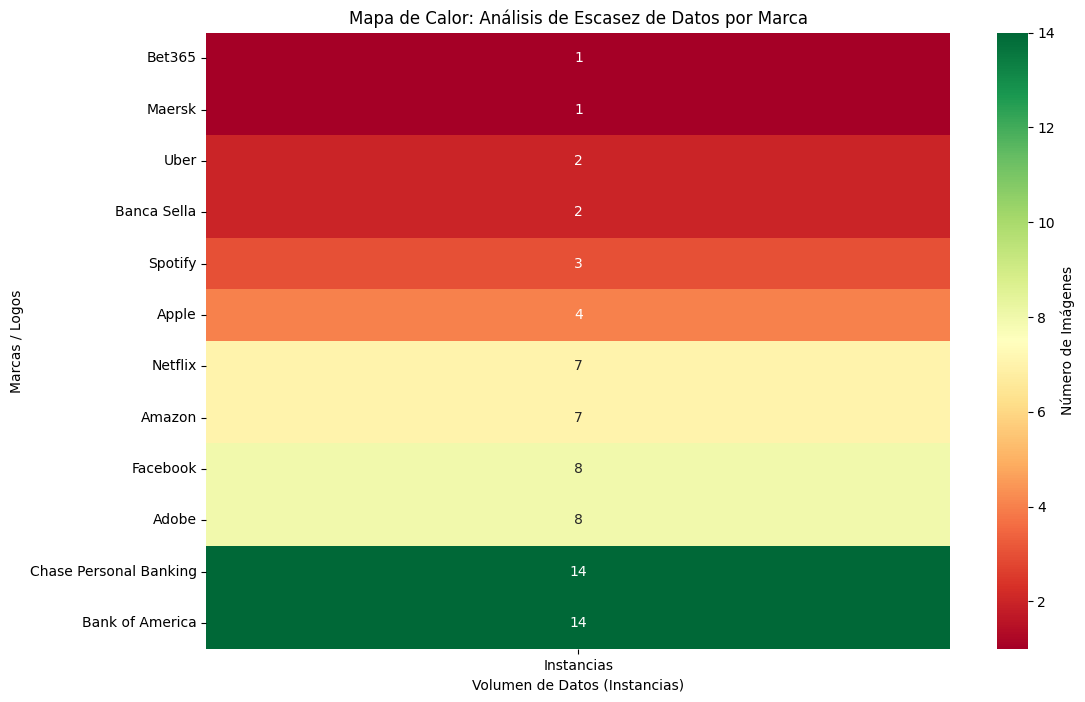

In [10]:
!pip install pandas seaborn matplotlib -q
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extraemos los datos críticos de tu reporte
# 'Instancias' es el número de veces que aparece el logo en tu set de validación
data = {
    'Marca': ['Bank of America', 'Chase Personal Banking', 'Adobe', 'Amazon', 'Facebook',
              'Apple', 'Banca Sella', 'Bet365', 'Maersk', 'Uber', 'Spotify', 'Netflix'],
    'Instancias': [14, 14, 8, 7, 8, 4, 2, 1, 1, 2, 3, 7],
    'mAP50': [0.977, 0.929, 0.393, 0.913, 0.955, 0.034, 0.003, 0.013, 0.199, 0.0, 0.12, 0.823]
}

df = pd.DataFrame(data).sort_values(by='Instancias')

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
# Usamos un mapa de color de Rojo a Verde (RdYlGn)
# El rojo indicará las marcas con MUY POCAS imágenes
sns.heatmap(df.set_index('Marca')[['Instancias']], annot=True, cmap='RdYlGn', cbar_kws={'label': 'Número de Imágenes'})

plt.title('Mapa de Calor: Análisis de Escasez de Datos por Marca')
plt.xlabel('Volumen de Datos (Instancias)')
plt.ylabel('Marcas / Logos')

# Añadir comentarios automáticos sobre los que tienen menos imágenes
for i, row in df.iterrows():
    if row['Instancias'] <= 2:
        print(f"⚠️ Alerta: La marca '{row['Marca']}' solo tiene {row['Instancias']} imágenes. Es imposible que el modelo aprenda así.")

plt.show()